# Overview of Final Project Graphs: Kyla Duran



In this project, I explore how marine heatwaves and ocean acidification have negative impacts on the economy.

This will be the first in a series of similar climate data science projects.

**Process of opening tar.gz file:**

**About the file**: tar is a collection of files that have been "glued" into one file. gz tells us the file was compressed.

**About the command**: -xzvf

**About the flags**: x= extract contents of file, z = uncompresses zip, -v = prints the names of the files as they are extracted from the tar, f = "file" tells system next "string" is the name of the file that we are trying to open.



In [ ]:

#Imports
import pandas as pd
import os

# (! = treat this as terminal code)

!wget https://www.ncei.noaa.gov/archive/archive-management-system/OAS/bin/prd/jquery/download/209268.21.21.tar.gz

#Opening and unzipping file
!tar -xzvf 209268.21.21.tar.gz

#finding the file
!ls
file = "0209268/21.21/data/0-data/events-US-1980-2024-Q4.csv"



--2026-07-13 04:06:08--  https://www.ncei.noaa.gov/archive/archive-management-system/OAS/bin/prd/jquery/download/209268.21.21.tar.gz
Resolving www.ncei.noaa.gov (www.ncei.noaa.gov)... 205.167.25.172, 205.167.25.171, 205.167.25.178, ...
Connecting to www.ncei.noaa.gov (www.ncei.noaa.gov)|205.167.25.172|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/x-gzip]
Saving to: ‘209268.21.21.tar.gz’

209268.21.21.tar.gz     [               <=>  ] 679.10K  80.1KB/s    in 8.5s    

2026-07-13 04:07:57 (80.1 KB/s) - ‘209268.21.21.tar.gz’ saved [695402]

0209268/0209268.21.21.xml
0209268/21.21/
0209268/21.21/about/
0209268/21.21/about/0209268_preview.png
0209268/21.21/about/0209268_map.jpg
0209268/21.21/about/1-email.txt
0209268/21.21/about/0209268_lonlat.txt
0209268/21.21/about/journal.txt
0209268/21.21/about/56491_R2A.pdf
0209268/21.21/about/0-email.txt
0209268/21.21/data/
0209268/21.21/data/0-data/
0209268/21.21/data/0-data/1980-2024-billion-dolla

In [ ]:
#reading in the file
df = pd.read_csv(file)
df.head()


,Weather and Climate Billion-Dollar Disasters to affect the U.S. from 1980-2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Cost values are in millions of dollars,NaN,NaN,NaN,NaN,NaN,NaN
1,Name,Disaster,Begin Date,End Date,CPI-Adjusted Cost,Unadjusted Cost,Deaths
2,Southern Severe Storms and Flooding (April 1980),Flooding,19800410,19800417,2749.4,706.8,7
3,Hurricane Allen (August 1980),Tropical Cyclone,19800807,19800811,2236.2,590,13
4,Central/Eastern Drought/Heat Wave (Summer-Fall...,Drought,19800601,19801130,40681.2,10020,1260


In [ ]:

#From Google Colab: https://colab.research.google.com/notebooks/data_table.ipynb

from google.colab import data_table
data_table.enable_dataframe_formatter()
df


,Weather and Climate Billion-Dollar Disasters to affect the U.S. from 1980-2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Cost values are in millions of dollars,NaN,NaN,NaN,NaN,NaN,NaN
1,Name,Disaster,Begin Date,End Date,CPI-Adjusted Cost,Unadjusted Cost,Deaths
2,Southern Severe Storms and Flooding (April 1980),Flooding,19800410,19800417,2749.4,706.8,7
3,Hurricane Allen (August 1980),Tropical Cyclone,19800807,19800811,2236.2,590,13
4,Central/Eastern Drought/Heat Wave (Summer-Fall...,Drought,19800601,19801130,40681.2,10020,1260
...,...,...,...,...,...,...,...
400,Hurricane Debby (August 2024),Tropical Cyclone,20240805,20240809,2476,2476,17
401,Hurricane Francine (September 2024),Tropical Cyclone,20240911,20240912,1291,1291,0
402,Hurricane Helene (September 2024),Tropical Cyclone,20240924,20240929,78721,78721,219
403,Hurricane Milton (October 2024),Tropical Cyclone,20241009,20241010,34250,34250,32


In [ ]:

#Lecture 18
import time
import datetime as dt

df = pd.read_csv(file, delimiter=",", header=2)
df.head()

#New df get only cyclone data = cyc_df
#Pseudo: df[give me every row where the first column says cyclone]
cyc_df = df[df.iloc[:, 1] == 'Tropical Cyclone']

#variables
#can't cast, have to do .astype(str)

start= cyc_df.iloc[:,2].astype(str)
end = cyc_df.iloc[:,3].astype(str)

#switched from trying to create dt objects to using python strings, simplier solution

#start= pd.to_datetime(cyc_df.iloc[:, 2], format='%Y%m%d')
start= pd.to_datetime(start, format='%Y%m%d')
#end = pd.to_datetime(cyc_df.iloc[:, 3], format='%Y%m%d')

end = pd.to_datetime(end,format="%Y%m%d")
#delta process from lecture video
length_time = end-start
print(length_time)

#for red dots
#using quantile instead of mean for percentages not averages that could taint results
q_length_time = length_time.quantile(.90)
print(q_length_time)





cost = cyc_df.iloc[:,4].astype(int)
deaths = cyc_df.iloc[:,6].astype(int)

#using quantile instead of mean for percentages not averages that could taint results
deaths_bench = deaths.quantile(.5)
print(deaths_bench)






1     4 days
10    3 days
19    4 days
20    2 days
21    4 days
       ...  
396   0 days
398   4 days
399   1 days
400   5 days
401   1 days
Length: 67, dtype: timedelta64[ns]
6 days 00:00:00
21.0


In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
cyc_df

,Name,Disaster,Begin Date,End Date,CPI-Adjusted Cost,Unadjusted Cost,Deaths
1,Hurricane Allen (August 1980),Tropical Cyclone,19800807,19800811,2236.2,590.0,13
10,Hurricane Alicia (August 1983),Tropical Cyclone,19830817,19830820,9450.0,3000.0,21
19,Hurricane Elena (September 1985),Tropical Cyclone,19850830,19850903,3788.4,1297.4,4
20,Hurricane Gloria (September 1985),Tropical Cyclone,19850926,19850928,2491.3,856.1,11
21,Hurricane Juan (October 1985),Tropical Cyclone,19851027,19851031,4340.4,1496.7,63
...,...,...,...,...,...,...,...
396,Hurricane Beryl (July 2024),Tropical Cyclone,20240708,20240708,7219.0,7219.0,46
398,Hurricane Debby (August 2024),Tropical Cyclone,20240805,20240809,2476.0,2476.0,17
399,Hurricane Francine (September 2024),Tropical Cyclone,20240911,20240912,1291.0,1291.0,0
400,Hurricane Helene (September 2024),Tropical Cyclone,20240924,20240929,78721.0,78721.0,219


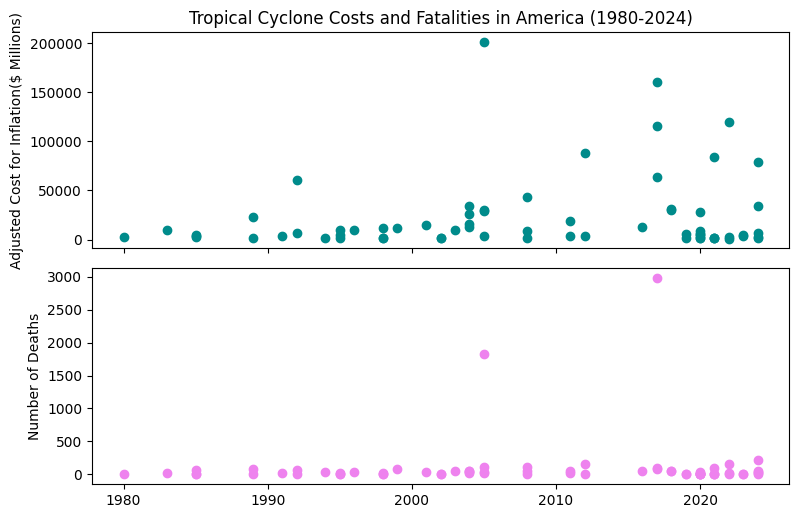

In [ ]:
#plotting

import matplotlib.pyplot as plt
import numpy as np
#import matplotlib.colors as mcolors Source: https://matplotlib.org/stable/gallery/color/named_colors.html

fig =plt.figure(figsize=[9,12])
#year = start.dt.strftime("%Y")
#fixing for better formating of axis labels
year = start.dt.strftime("%Y").astype(int)
#c = np.where(deaths <= deaths_bench, "violet", "grey")

ax1 = plt.subplot2grid((8,2),(0,0),rowspan=2,colspan=2) #catches per year
ax2 = plt.subplot2grid((8,2),(2,0), rowspan=2,colspan=2)

ax1.xaxis.set_ticklabels([])

ax1.set_title('Tropical Cyclone Costs and Fatalities in America (1980-2024)')
ax1.set_ylabel('Adjusted Cost for Inflation($ Millions)')
ax2.set_ylabel('Number of Deaths')

ax1.scatter(year, cost, color="darkcyan", marker="o")
ax2.scatter(year,deaths, color="violet")


#can do a second axis later if you want
#plt.scatter(year, deaths, color =" c", marker= "o")


# plt.xlabel('Year')
# plt.ylabel('Cost ($ Millions)')
# plt.title('Cyclone Costs Over Years In America')
# plt.show()



#recommend to from matplotlib website how to get dots with lines
#https://stackoverflow.com/questions/20130227/how-to-connect-scatterplot-points-with-line-using-matplotlib




**Citation for dataset:**


Historical Maine Landings for Lobster from 1880 to 2025.

Data Source: Maine Department of Marine Resources. (2026). Historical Maine Fisheries Landings Data [Data set]. https://www.maine.gov/dmr/fisheries/commercial/landings-program/historical-data (Accessed: July 11, 2026).

Last Updated 2/6/2026

Converted from PDF to csv by Kyla

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/kduran-stack/climate_collection_kd/main/data/lobster_maine_kd.csv"

lobster = pd.read_csv(url)

lobster.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADJUSTED,NUMBER OF,NUMBER OF,WATER TEMP AT
1,YEAR,SPECIES,METRIC\nTONS,POUNDS*,POUNDS(millions)*,VALUE,VALUE(millions),PRICE/LB,ADJUSTED\nPRICE/LB,ADJUSTED\nVALUE,VALUE\n(millions),LICENSE\nHOLDERS�,TRAPS -MILLIONS,BOOTHBAY HARBOR\nSTATION (C)
2,1880,"LOBSTER, AMERICAN",NaN,"14,235,102",14.2351,"$300,000",0.3,$0.02,NaN,NaN,NaN,"2,763",0.104,NaN
3,1881,"LOBSTER, AMERICAN",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1882,"LOBSTER, AMERICAN",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


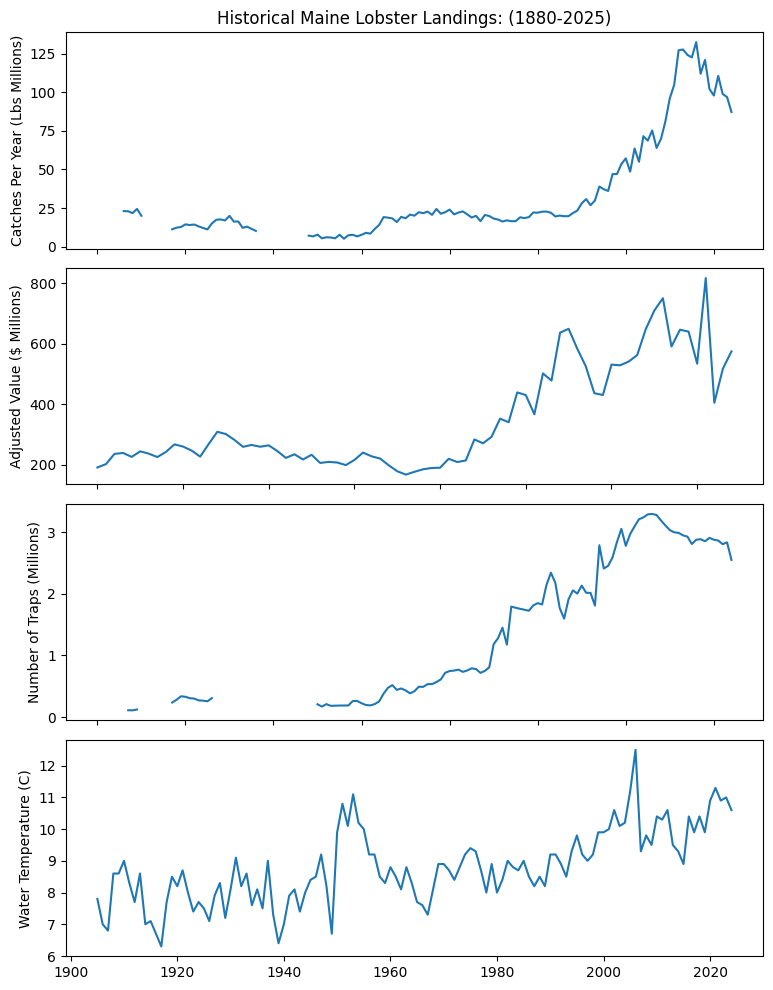

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file cleanly
df = pd.read_csv(url,thousands=",", skiprows=2)

#removing symbols from csv
df.iloc[:, 5] = df.iloc[:, 5].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
df.iloc[:, 7] = df.iloc[:, 7].astype(str).str.replace('$', '').astype(float)
df.iloc[:,1] = df.iloc[:,1].astype(str).str.replace(",", " ")
df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors='coerce')

#variables
year = df.iloc[:,0]
species = df.iloc[:,1]
metric_tons= df.iloc[:,2]
pounds= df.iloc[:,3]
pounds_millions= df.iloc[:,4]
dollar_value= df.iloc[:,5]
dollar_value_millions= df.iloc[:,6]
price_per_lb = df.iloc[:,7]
adjusted_price_pound = df.iloc[:,8]
adjusted_value = df.iloc[:,9]
adjusted_value_millions = df.iloc[:,10]
num_license_holders = df.iloc[:,11]
traps_millions= df.iloc[:,12]
water_temp_cel = df.iloc[:,13]

#print(df.head())

#plotting
fig =plt.figure(figsize=[9,12])

#defining axis
ax1 = plt.subplot2grid((8,2),(0,0),rowspan=2,colspan=2) #catches per year
ax2 = plt.subplot2grid((8,2),(2,0), rowspan=2,colspan=2)
ax3 = plt.subplot2grid((8,2),(4,0), rowspan=2, colspan=2)
ax4= plt.subplot2grid((8,2),(6,0), rowspan=2, colspan=2)

ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])
ax3.xaxis.set_ticklabels([])


ax1.set_title('Historical Maine Lobster Landings: (1880-2025)')
ax1.set_ylabel('Catches Per Year (Lbs Millions)')
ax2.set_ylabel('Adjusted Value ($ Millions)')
ax3.set_ylabel('Number of Traps (Millions)')
ax4.set_ylabel('Water Temperature (C)')


ax1.plot(year,pounds_millions)
ax2.plot(year,adjusted_value_millions)
ax3.plot(year, traps_millions)
ax4.plot(year, water_temp_cel)












**Lessons Learned From Working With a Large, Messy Dataset: Part 1**

1. Read in raw data and print dimensions (row, col) to understand scale of data.


*Note: Colab will not show you the full scale of the data. To get a sense of the variables, you print them and see what you are dealing with.


For instance: dimensions, variables, etc.


2. Cleaning Header

a. In this case the headers for the first column were all fused. To separate them, use df.iloc[0].str.split(",", expand=True). (or instead of df.iloc[0] you can single out the header column, which will be useful later)

expand = True --> every separated word gets put into a new column.

b. After columns are separated rename the columns. Create a list of base words, then plug that list into df.columns = names[:df.shape[1]].

where .shape always gives you the dimensions of the table.

We can use this command if we isolated the header.

header = df.iloc[1], gives us a "duplicate" data set with just the first column, where we can swap out the headers with the new list of names.

c. Recombining everything. With pd.concat we can do : new_header + old_header
d. Dropping old header: after they are combined we can .drop() the old header and just leaving the new header you created.

3. Ensure the rest of data is clean

(You will know what things you need to clean by printing out variables like explained in step 1. )

a. No white space, which could cause things like "2020 " to crash.

Recommended step by Pandas API: df.columns.str.strip()



In [ ]:
#dataset catches major fishing areas: /content/catches_major_fishing_areas.tsv.gz
#tsv (tab separated values) requires \t for separator (same way csv requires , for separator)


url = "https://raw.githubusercontent.com/kduran-stack/climate_collection_kd/main/data/catches_major_fishing_areas.tsv.gz"

df= pd.read_csv(url,sep="\t",compression="gzip")

print(list(df.columns))

df.head()


['freq,species,fishreg,unit,geo\\TIME_PERIOD', '2000 ', '2001 ', '2002 ', '2003 ', '2004 ', '2005 ', '2006 ', '2007 ', '2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ']


,"freq,species,fishreg,unit,geo\TIME_PERIOD",2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"A,AAA,0,TLW,DK",:,:,:,:,:,:,:,:,:,...,:,:,:,:,:,0,:,:,:,:
1,"A,AAA,0,TLW,EU27_2020",:,:,:,:,:,:,:,:,:,...,:,:,:,:,0,0,:,:,0 n,:
2,"A,AAA,0,TLW,EU28",:,:,:,:,:,:,:,:,:,...,:,:,:,:,0,:,:,:,:,:
3,"A,AAA,0,TLW,IE",:,:,:,:,:,:,:,:,:,...,:,:,:,:,0,0,:,:,:,:
4,"A,AAA,0,TLW,NL",:,:,:,:,:,:,:,:,:,...,:,:,:,:,:,:,:,:,0 n,:


In [ ]:

# isolating bad header
header= df.columns[0]

# Splitting the header (The header is like a sentence with no spaces. I am separating them, and giving each word its own column)
df_header = df[header].str.split(',', expand=True)

# renaming the header with new column titles
names = ['freq', 'species', 'fishreg', 'unit','geo']
df_header.columns = names[:df_header.shape[1]]
print(df_header.columns)

# Combining everything

df_clean = pd.concat([df_header, df.drop(columns=[header])], axis=1)


#removing spaces from titles
df_clean.columns = df_clean.columns.str.strip()
print(df_clean.columns)


print(df_clean.head())


"""
Notes from Eurostat reference metadata website
freq = A = annual
unit = TLW = tonnes live weight
geo = country, EU27_2020 is the TLW for all countries in the 27 region(atlantic, northeast)
"""

Index(['freq', 'species', 'fishreg', 'unit', 'geo'], dtype='object')
Index(['freq', 'species', 'fishreg', 'unit', 'geo', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021', '2022', '2023', '2024'],
      dtype='object')
  freq species fishreg unit        geo 2000 2001 2002 2003 2004  ... 2015  \
0    A     AAA       0  TLW         DK   :    :    :    :    :   ...   :    
1    A     AAA       0  TLW  EU27_2020   :    :    :    :    :   ...   :    
2    A     AAA       0  TLW       EU28   :    :    :    :    :   ...   :    
3    A     AAA       0  TLW         IE   :    :    :    :    :   ...   :    
4    A     AAA       0  TLW         NL   :    :    :    :    :   ...   :    

  2016 2017 2018 2019 2020 2021 2022 2023 2024  
0   :    :    :    :    0    :    :    :    :   
1   :    :    :    0    0    :    :   0 n   :   
2   :    :    :    0    :

'\nNotes from Eurostat reference metadata website\nfreq = A = annual\nunit = TLW = tonnes live weight\ngeo = country, EU27_2020 is the TLW for all countries in the 27 region(atlantic, northeast)\n'

In [ ]:
#Determining what species to use from various papers including Global Empirical Assessments of Marine Heatwaves' Impact on Fisheries Production and Economic Value (Arenas,2025)

"""
Most likely to migrate: Shrimp, prawns, tunas (alb), billfish,shark, rays
Cold water indicators; atlantic herring (her), pollack (abk) cod (cod), mackerels (mac), sprat (spr), sardines (pil)
"""

'\nMost likely to migrate: Shrimp, prawns, tunas (alb), billfish,shark, rays\nCold water indicators; atlantic herring (her), pollack (abk) cod (cod), mackerels (mac), sprat (spr), sardines (pil)\n'

**Lessons Learned From Working With a Large, Messy Dataset: Part 2**

# Wide data

In the data: the years are horizontal, which has been causing problems while trying to plot. I had to transpose the the columns so that it was like the data I had for other graphs.
Ex:
Year
2022
2025

The recommended way to do this is either the pd.wide_to_long pandas function or pd.melt. In this case, I chose pd.melt because I have worked with it before.

Youtube source:
https://www.youtube.com/watch?v=DCqWZ0DGVqw



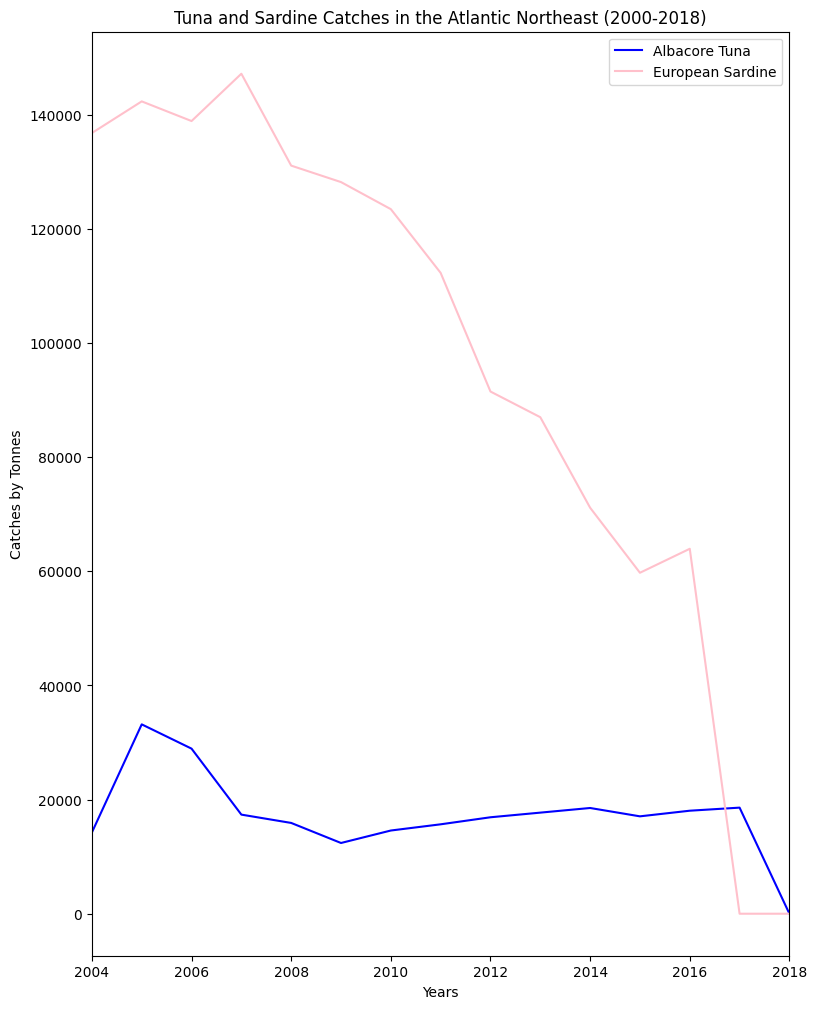

In [ ]:


#wide to long for years column

#separating out the year column, grabbing each year only
year_columns = list(df_clean.iloc[:, 5:30].columns)
#print(list(year_columns))
df_new= pd.melt(df_clean,id_vars=["freq", "unit", "fishreg", "species", "geo"],var_name="Year",value_vars=year_columns,value_name="Catch_Tonnes")

#print(df_new.head())

#gather species


# #ensuring year column is seen as numbers not strings (like I had to do for the first plot)
df_new["Year"] = df_new['Year'].astype(int)
#without the errors="coerce" code wouldn't run, this line tells python that if it finds a
df_new["Catch_Tonnes"] = pd.to_numeric(df_new["Catch_Tonnes"], errors="coerce").fillna(0)

#df_new["Catch_Tonnes"] = (df_new["Catch_Tonnes"]).fillna(0)

#creating a "new" df for each species I'll be graphing

#a. Pandalid shrimp focusing on the 27 region
shrimp_df = df_new[(df_new["species"] == "PAN") & (df_new["fishreg"]).isin(["27"])]
#print(shrimp_df.head(10))
#plus tropical region
tuna_df = df_new[(df_new["species"] == "ALB") & (df_new["fishreg"]).isin(["27","21"])]


#print(tuna_df.head(10))
#sardine
sardine_df = df_new[(df_new["species"] == "PIL") & (df_new["fishreg"] == "27")]
#print(sardine_df.head(10))


#region EU27_2020 (only)

"""

Data fixes I needed to clean up graph:

.groupby["Years"] organized data by time, stopped a zig zag pattern from appearing on the graph, but it had to be coupled with the following:

["Catch_Tonnes].sum() --> this adds the data for each of the new organized dates

.reset_index() --> after .sum, all the things it added together are put in one "space" all the spaces of the numbers that were combined are empty. Reseting the index makes sure that index is synced with the data
and doesn't account for the new holes created by .sum(). The code will not run without this line.

"""

#region1_shrimp= shrimp_df[shrimp_df["geo"]== "EU27_2020"]
region1_shrimp = shrimp_df[shrimp_df["geo"] == "EU27_2020"].groupby("Year")["Catch_Tonnes"].sum().reset_index()
# region1_tuna= tuna_df[tuna_df["geo"]== "EU27_2020"]
# region1_sardine= sardine_df[sardine_df["geo"]== "EU27_2020"]
region1_tuna   = tuna_df[tuna_df["geo"] == "EU27_2020"].groupby("Year")["Catch_Tonnes"].sum().reset_index()
region1_sardine = sardine_df[sardine_df["geo"] == "EU27_2020"].groupby("Year")["Catch_Tonnes"].sum().reset_index()

fig = plt.figure(figsize=(9,12))

#plt.plot(region1_shrimp["Year"],region1_shrimp["Catch_Tonnes"], color="grey")
plt.plot(region1_tuna["Year"],region1_tuna["Catch_Tonnes"], color="blue", label="Albacore Tuna")
plt.plot(region1_sardine["Year"],region1_sardine["Catch_Tonnes"], color="pink", label ="European Sardine")
plt.xlabel("Years")
plt.ylabel("Catches by Tonnes")
plt.title("Tuna and Sardine Catches in the Atlantic Northeast (2000-2018)")

plt.xlim(2004, 2018)
plt.legend()
plt.show()





# Last graph focusing on the pelagic vs demersal reaction to MHWs, in Estonia. An area with some of the most frequent and intense MHWs.

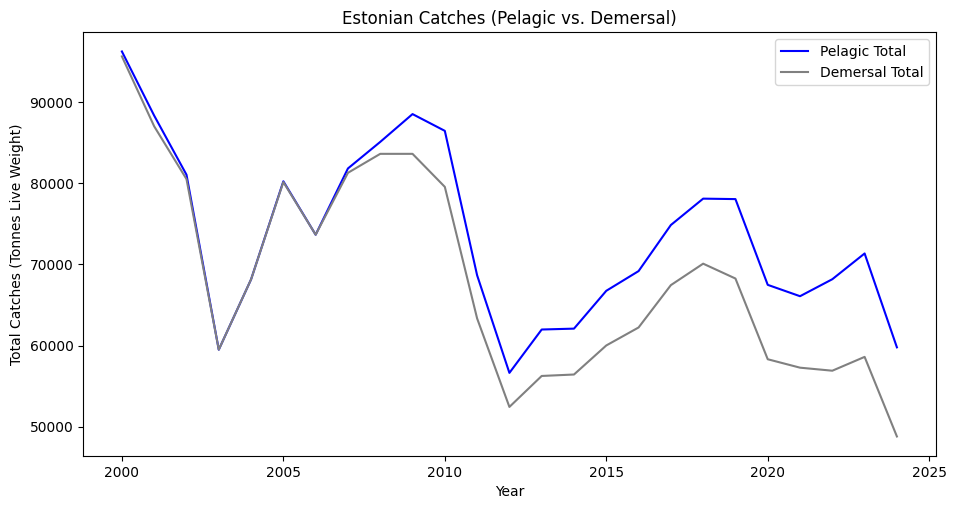

In [ ]:
est_df = df_new[(df_new["geo"] == "EE") & (df_new["fishreg"] == "27")]
#codes: Demersal (F07), pelagic (F08)

pelagic = est_df[est_df["species"] == "F08"].groupby("Year")["Catch_Tonnes"].sum()#.reset_index()
demersal = est_df[est_df["species"] == "F07"].groupby("Year")["Catch_Tonnes"].sum()#.reset_index()

# plotting
plt.figure(figsize=(11, 5.5))


# plt.plot(pelagic["Years"], pelagic["Catch_Tonnes"], color="blue", label="Pelagic Total")
# plt.plot(demersal["Years"], demersal["Catches_Tonnes"], color="grey", label="Demersal Total")

# using this: pelagic["Years"] did not work, recommended fix was using .index and .values instead
plt.plot(pelagic.index, pelagic.values, color="blue", label="Pelagic Total")
plt.plot(demersal.index, demersal.values, color="grey", label="Demersal Total")

#labels
plt.title("Estonian Catches (Pelagic vs. Demersal)")
plt.xlabel("Year")
plt.ylabel("Total Catches (Tonnes Live Weight)")
#plt.xlim(2008, 2023)


plt.legend()

plt.show()
